# Dogs vs Cats — HW2 Q2
**Model:** ResNet50 (Transfer Learning + Fine-Tuning)
**Goal:** Log Loss < 0.05 on Kaggle leaderboard

In [21]:
# Block 1 — Imports
import os, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
IMG_SIZE   = 224
BATCH_SIZE = 32

print('TF version:', tf.__version__)

TF version: 2.19.0


In [22]:
import zipfile

# Unzip train and test files
with zipfile.ZipFile('/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/train.zip', 'r') as z:
    z.extractall('/kaggle/working/')

with zipfile.ZipFile('/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/test.zip', 'r') as z:
    z.extractall('/kaggle/working/')

print('Train images:', len(os.listdir('/kaggle/working/train')))
print('Test images :', len(os.listdir('/kaggle/working/test')))

Train images: 25000
Test images : 12500


In [23]:
# Block 3 — Organise into class folders
base_dir  = '/kaggle/working/data'
train_dir = os.path.join(base_dir, 'train')
cat_dir   = os.path.join(train_dir, 'cats')
dog_dir   = os.path.join(train_dir, 'dogs')

os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

for fname in os.listdir('/kaggle/working/train'):
    dst = cat_dir if 'cat' in fname else dog_dir
    shutil.copy(f'/kaggle/working/train/{fname}', f'{dst}/{fname}')

print('Cats:', len(os.listdir(cat_dir)))
print('Dogs:', len(os.listdir(dog_dir)))

Cats: 12500
Dogs: 12500


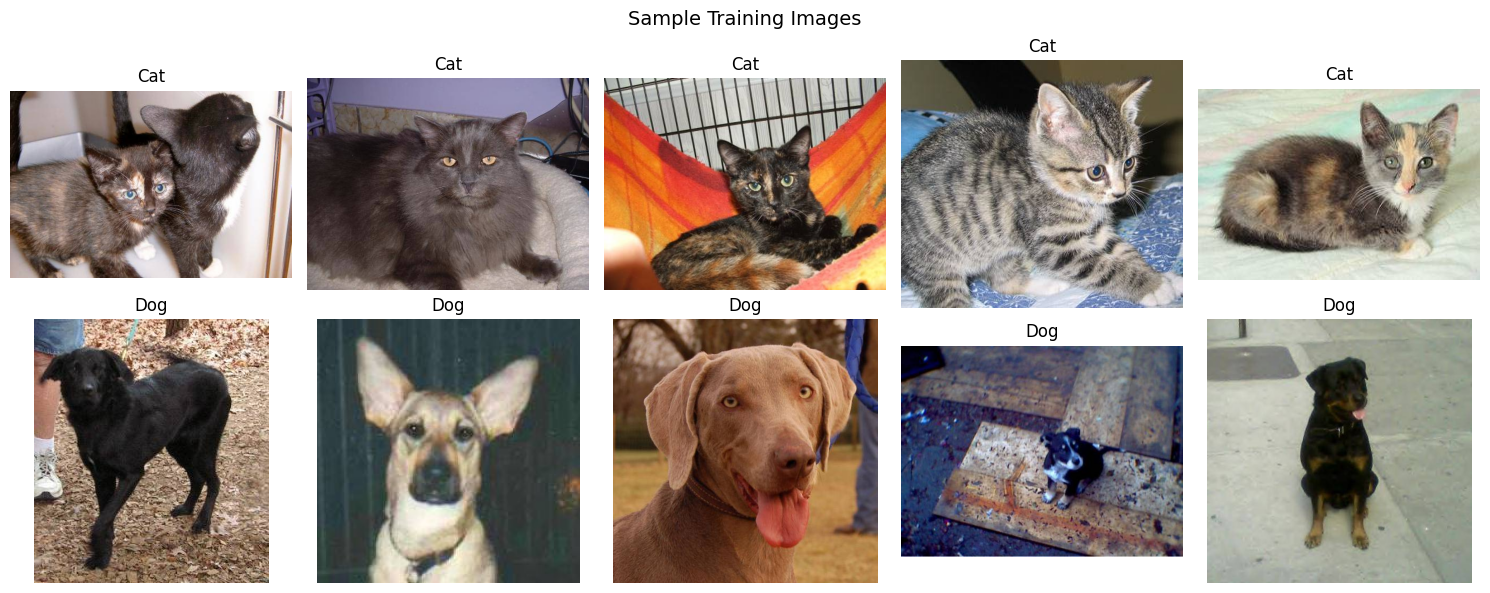

In [24]:
# Block 4 — Visualise sample images
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images', fontsize=14)

for i, fname in enumerate(os.listdir(cat_dir)[:5]):
    axes[0, i].imshow(Image.open(f'{cat_dir}/{fname}'))
    axes[0, i].set_title('Cat'); axes[0, i].axis('off')

for i, fname in enumerate(os.listdir(dog_dir)[:5]):
    axes[1, i].imshow(Image.open(f'{dog_dir}/{fname}'))
    axes[1, i].set_title('Dog'); axes[1, i].axis('off')

plt.tight_layout(); plt.show()

## Model 1 — Simple CNN Baseline
Establishes a performance baseline before applying transfer learning.

In [25]:
# Block 5 — CNN Baseline generators (rescale only, no transfer learning preprocessing)
IMG_SIZE   = 224
BATCH_SIZE = 32

cnn_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

cnn_train_gen = cnn_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='training', seed=42
)
cnn_val_gen = cnn_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='validation', seed=42
)
print('Classes:', cnn_train_gen.class_indices)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Classes: {'cats': 0, 'dogs': 1}


In [26]:
# Block 6 — CNN model architecture
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Block 7 — Train CNN baseline
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = cnn_model.fit(
    cnn_train_gen, validation_data=cnn_val_gen,
    epochs=6, callbacks=[early_stop]
)

print(f'Best CNN Val Accuracy : {max(history_cnn.history["val_accuracy"]):.4f}')
print(f'Best CNN Val Loss     : {min(history_cnn.history["val_loss"]):.4f}')

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1204s 2s/step - accuracy: 0.5808 - loss: 0.7027 - val_accuracy: 0.6798 - val_loss: 0.6137
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1197s 2s/step - accuracy: 0.6967 - loss: 0.5806 - val_accuracy: 0.7482 - val_loss: 0.5166
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1217s 2s/step - accuracy: 0.7313 - loss: 0.5295 - val_accuracy: 0.7614 - val_loss: 0.4849
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1277s 2s/step - accuracy: 0.7677 - loss: 0.4858 - val_accuracy: 0.7874 - val_loss: 0.4645
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1282s 2s/step - accuracy: 0.7829 - loss: 0.4630 - val_accuracy: 0.7998 - val_loss: 0.4288
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 1284s 2s/step - accuracy: 0.7959 - loss: 0.4344 - val_accuracy: 0.8084 - val_loss: 0.4113
Best CNN Val Accuracy : 0.8084
Best CNN Val Loss     : 0.4113


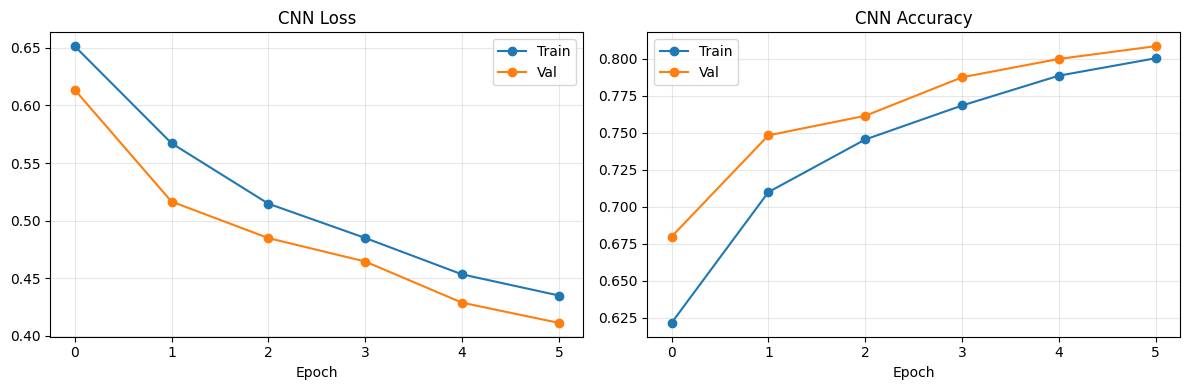

In [28]:
# Block 8 — Plot CNN results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['loss'],     label='Train', marker='o')
axes[0].plot(history_cnn.history['val_loss'], label='Val',   marker='o')
axes[0].set_title('CNN Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['accuracy'],     label='Train', marker='o')
axes[1].plot(history_cnn.history['val_accuracy'], label='Val',   marker='o')
axes[1].set_title('CNN Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Model 2 — ResNet50 Transfer Learning
**Why ResNet50:** Pre-cached on Kaggle (no download needed). Strong ImageNet features transfer well to animal classification.

**Strategy:**
1. Freeze base → train classification head only (warmup)
2. Unfreeze top 30 layers → fine-tune at very low LR

**Augmentation:** horizontal flip, rotation, zoom — helps generalise to unseen poses without distorting the animal shape.

**Overfitting prevention:** Dropout(0.5), EarlyStopping, ReduceLROnPlateau, 20% validation split.

In [29]:
# Block 9 — ResNet50 generators
# preprocess_input handles normalisation — NO rescale=1./255
res_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

train_gen = res_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='training', seed=42
)
val_gen = res_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='validation', seed=42
)
print('Classes:', train_gen.class_indices)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Classes: {'cats': 0, 'dogs': 1}


In [30]:

import os

# Find the weights file
WEIGHTS_PATH = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        if 'resnet50' in f.lower() and 'notop' in f.lower():
            WEIGHTS_PATH = os.path.join(dirname, f)
            print('Found:', WEIGHTS_PATH)
            break

if WEIGHTS_PATH is None:
    print('NOT FOUND — listing all files in /kaggle/input:')
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for f in filenames:
            print(os.path.join(dirname, f))

base_model = ResNet50(
    weights=WEIGHTS_PATH,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Found: /kaggle/input/models/sherkoranga/resnet50_weights_tf_dim_ordering_tf_kernels_notop/tensorflow2/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,120,705 (92.01 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [31]:
# Recreate generators
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 224
BATCH_SIZE = 32
train_dir  = '/kaggle/working/data/train'

res_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

train_gen = res_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='training', seed=42
)
val_gen = res_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='validation', seed=42
)
print('Classes:', train_gen.class_indices)
print('Ready!')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Classes: {'cats': 0, 'dogs': 1}
Ready!


In [32]:
# Block 11 — Phase 1: Warmup (frozen base, train head only)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

history_warmup = model.fit(
    train_gen, validation_data=val_gen,
    epochs=8, callbacks=[early_stop, reduce_lr]
)

print(f'Best Warmup Val Accuracy : {max(history_warmup.history["val_accuracy"]):.4f}')
print(f'Best Warmup Val Loss     : {min(history_warmup.history["val_loss"]):.4f}')

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2067s 3s/step - accuracy: 0.9616 - loss: 0.1201 - val_accuracy: 0.9808 - val_loss: 0.0572 - learning_rate: 0.0010
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2054s 3s/step - accuracy: 0.9787 - loss: 0.0637 - val_accuracy: 0.9808 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2044s 3s/step - accuracy: 0.9797 - loss: 0.0548 - val_accuracy: 0.9832 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2026s 3s/step - accuracy: 0.9838 - loss: 0.0448 - val_accuracy: 0.9826 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2040s 3s/step - accuracy: 0.9844 - loss: 0.0413 - val_accuracy: 0.9828 - val_loss: 0.0470 - learning_rate: 0.0010
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 2031s 3s/step - accuracy: 0.9850 - loss: 0.0406 - val_accuracy: 0.9828 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9834 - loss: 0.038

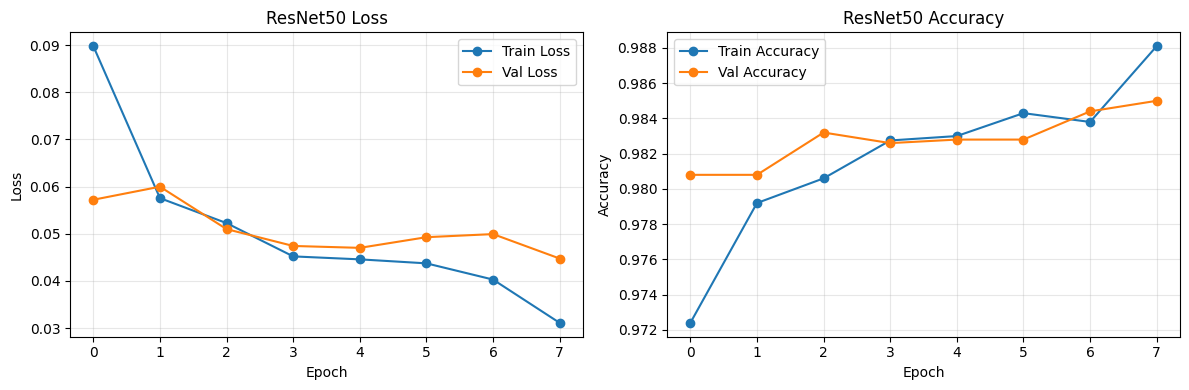

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_warmup.history['loss'], label='Train Loss', marker='o')
plt.plot(history_warmup.history['val_loss'], label='Val Loss', marker='o')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_warmup.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_warmup.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Block 14 — Evaluate on validation set
val_loss, val_acc = model.evaluate(val_gen)
print(f'Final Val Loss     : {val_loss:.4f}')
print(f'Final Val Accuracy : {val_acc:.4f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.9832 - loss: 0.0460
Final Val Loss     : 0.0466
Final Val Accuracy : 0.9838


In [ ]:
# Block 15 — Generate test predictions and create submission
# Use same preprocessing as training — critical for correct predictions
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_directory(
    '/kaggle/working/',
    classes=['test'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False,
    class_mode=None
)

predictions = model.predict(test_gen, verbose=1)

# Build submission
filenames = test_gen.filenames
ids = [int(f.split('/')[1].split('.')[0]) for f in filenames]

submission = pd.DataFrame({'id': ids, 'label': predictions.flatten()})
submission = submission.sort_values('id').reset_index(drop=True)
submission.to_csv('/kaggle/working/submission.csv', index=False)

print('submission.csv saved!')
print(f'Shape: {submission.shape}')
print(submission['label'].describe())

Found 12500 images belonging to 1 classes.
391/391 ━━━━━━━━━━━━━━━━━━━━ 959s 2s/step
submission.csv saved!
Shape: (12500, 2)
   id         label
0   1  1.000000e+00
1   2  1.000000e+00
2   3  1.000000e+00
3   4  9.999985e-01
4   5  2.607391e-14
5   6  2.384160e-08
6   7  2.421566e-15
7   8  8.636293e-11
8   9  5.244961e-13
9  10  2.073918e-06

Prediction stats:
count    1.250000e+04
mean     5.060190e-01
std      4.937406e-01
min      1.086507e-25
25%      1.196897e-09
50%      6.962311e-01
75%      1.000000e+00
max      1.000000e+00
Name: label, dtype: float64
